<a href="https://colab.research.google.com/github/dee431/-Student-Career-Success-Prediction-Dataset/blob/main/%F0%9F%8F%86%F0%9F%A5%87%F0%9F%A5%88%F0%9F%A5%89%F0%9F%8F%85%F0%9F%8E%96%EF%B8%8FStudent_Career_Success_Prediction_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Student Placement Prediction Using ML**🎓

What this notebook covers:

Importing libraries & loading data
Exploratory Data Analysis (EDA)
Data cleaning & leakage check
Feature preprocessing
Model building (Logistic Regression, Random Forest, LightGBM)
Model evaluation & comparison
Feature importance
Conclusion

In [1]:
# 1. Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

**load the Dataset**

In [3]:
df = pd.read_csv('/content/student_career_success_dataset-selected-columns.csv')
print("Shape of dataset:", df.shape)
print(df.head())

Shape of dataset: (50000, 10)
  Student_ID  Age  Gender University_Year                   Major  \
0   ST000001   22    Male       Sophomore        Computer Science   
1   ST000002   20  Female        Freshman        Computer Science   
2   ST000003   23    Male          Senior  Information Technology   
3   ST000004   23  Female          Senior  Information Technology   
4   ST000005   23  Female          Senior    Software Engineering   

   Attendance_Percentage  Study_Hours_Per_Week  CGPA Academic_Performance  \
0                     86                    21  3.28                 Good   
1                     64                    18  2.53                 Poor   
2                     75                    19  2.83              Average   
3                     80                    19  2.80              Average   
4                     73                    19  2.93              Average   

   Programming_Skill  
0                  9  
1                  6  
2                  8  


In [4]:
# Basic info about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             50000 non-null  object 
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   University_Year        50000 non-null  object 
 4   Major                  50000 non-null  object 
 5   Attendance_Percentage  50000 non-null  int64  
 6   Study_Hours_Per_Week   50000 non-null  int64  
 7   CGPA                   50000 non-null  float64
 8   Academic_Performance   50000 non-null  object 
 9   Programming_Skill      50000 non-null  int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 3.8+ MB


In [5]:
# Check for missing values
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
University_Year,0
Major,0
Attendance_Percentage,0
Study_Hours_Per_Week,0
CGPA,0
Academic_Performance,0
Programming_Skill,0


**3. Exploratory Data Analysis (EDA)**

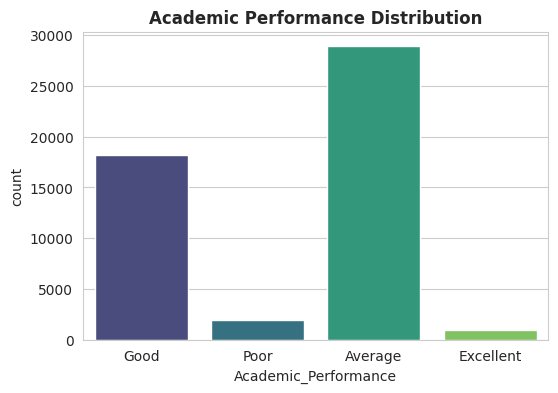

Academic_Performance
Average      57.780
Good         36.336
Poor          3.912
Excellent     1.972
Name: proportion, dtype: float64


In [7]:
# Target variable distribution (using Academic_Performance as a proxy)
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Academic_Performance', palette='viridis')
plt.title('Academic Performance Distribution',fontweight='bold')
plt.show()

print(df['Academic_Performance'].value_counts(normalize=True) * 100)

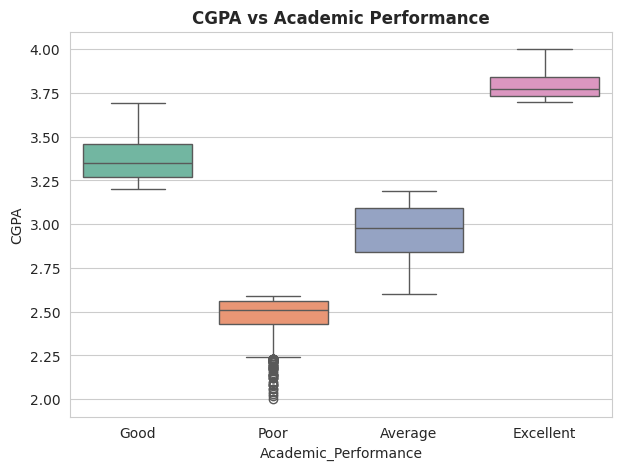

In [9]:
# CGPA vs Academic Performance
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Academic_Performance', y='CGPA', palette='Set2')
plt.title('CGPA vs Academic Performance',fontweight='bold')
plt.show()

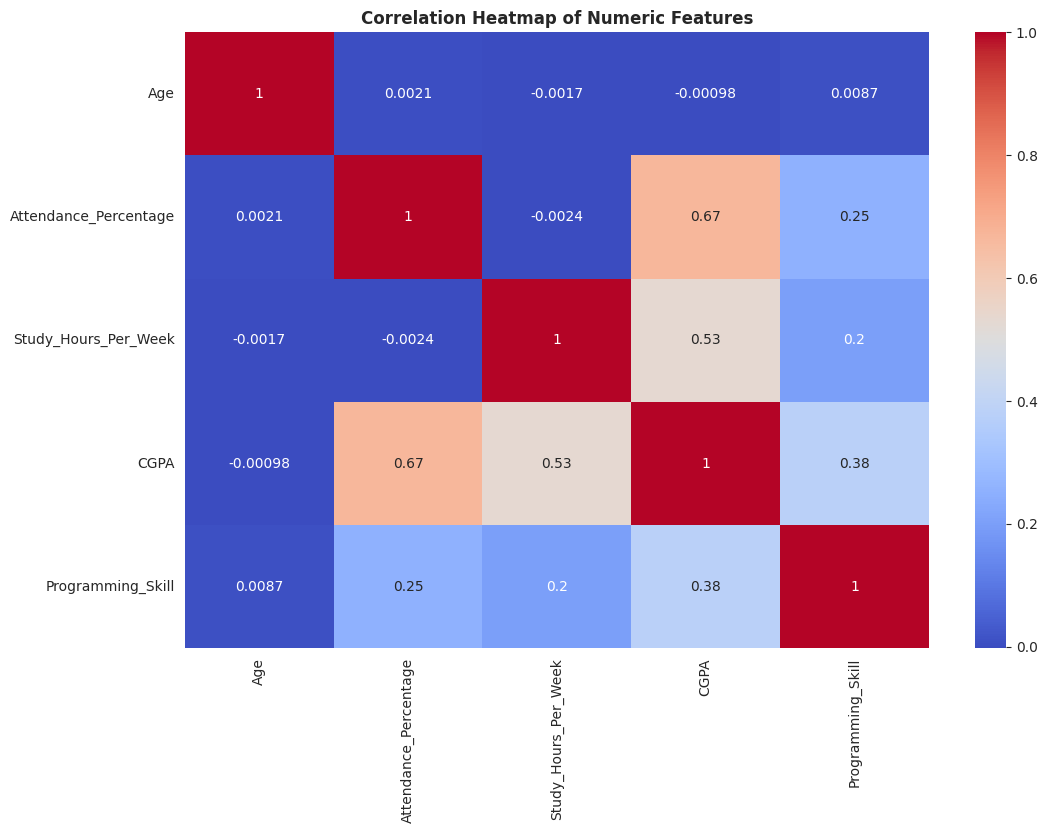

In [10]:
# Correlation heatmap of numeric features
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=True)
plt.title('Correlation Heatmap of Numeric Features',fontweight='bold')
plt.show()

**4. Handling Data Leakage**

In [12]:
target = 'Academic_Performance'

# Only Student_ID exists from the original leakage_cols list
leakage_cols = ['Student_ID']

X = df.drop(columns=leakage_cols + [target])
# Map the Academic_Performance categories to numerical values
y = df[target].map({'Excellent': 3, 'Good': 2, 'Average': 1, 'Poor': 0})

print("Features used:", list(X.columns))
print(f"Target: {target} (0=Poor, 1=Average, 2=Good, 3=Excellent)")

Features used: ['Age', 'Gender', 'University_Year', 'Major', 'Attendance_Percentage', 'Study_Hours_Per_Week', 'CGPA', 'Programming_Skill']
Target: Academic_Performance (0=Poor, 1=Average, 2=Good, 3=Excellent)


**Preprocessing**

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Separate numeric and categorical columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols)

# Train-test split (80-20), stratified to keep class ratio same in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)

Categorical columns: ['Gender', 'University_Year', 'Major']
Numeric columns: ['Age', 'Attendance_Percentage', 'Study_Hours_Per_Week', 'CGPA', 'Programming_Skill']
Train size: (40000, 8)  Test size: (10000, 8)


In [14]:
# Preprocessing pipeline: scale numeric features, one-hot encode categorical ones
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

**6. Model Building**

Logistic Regression — simple linear baseline
Random Forest — ensemble of decision trees
LightGBM — fast gradient boosting model


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42, class_weight='balanced'),
    'LightGBM': LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=42,
                                class_weight='balanced', verbose=-1)
}

results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)

    preds = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test) # Get probabilities for all classes

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='weighted') # Specify average for multiclass
    auc = roc_auc_score(y_test, proba, multi_class='ovr', average='weighted') # Specify multi_class and average

    results[name] = {'model': pipe, 'accuracy': acc, 'f1': f1, 'auc': auc}
    print(f"{name}: Accuracy={acc:.4f} | F1-score={f1:.4f} | ROC-AUC={auc:.4f}")

Logistic Regression: Accuracy=0.9768 | F1-score=0.9778 | ROC-AUC=0.9995
Random Forest: Accuracy=1.0000 | F1-score=1.0000 | ROC-AUC=1.0000
LightGBM: Accuracy=1.0000 | F1-score=1.0000 | ROC-AUC=1.0000


**Model comparison**

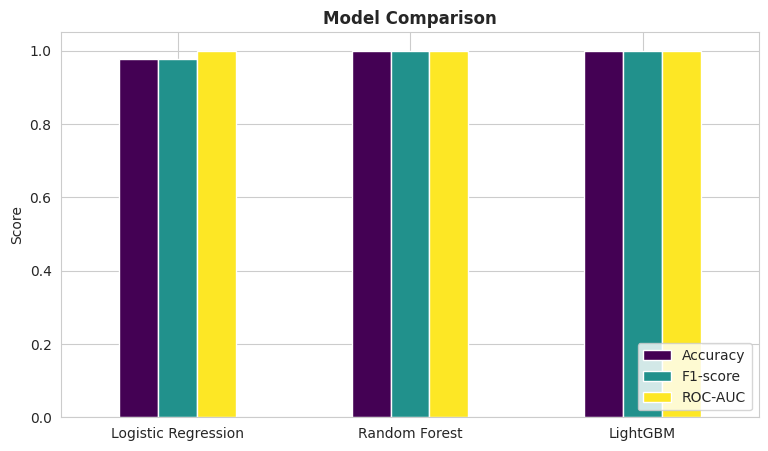

,Accuracy,F1-score,ROC-AUC
Logistic Regression,0.9768,0.977773,0.999473
Random Forest,1.0000,1.000000,1.000000
LightGBM,1.0000,1.000000,1.000000


In [17]:
results_df = pd.DataFrame({
    name: {'Accuracy': v['accuracy'], 'F1-score': v['f1'], 'ROC-AUC': v['auc']}
    for name, v in results.items()
}).T

results_df.plot(kind='bar', figsize=(9,5), colormap='viridis')
plt.title('Model Comparison',fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

results_df

In [18]:
# Pick the best model based on Accuracy
best_model_name = results_df['Accuracy'].idxmax()
best_pipe = results[best_model_name]['model']
print("Best model:", best_model_name)

Best model: Random Forest


**Detailed evalution of the best model**

              precision    recall  f1-score   support

        Poor       1.00      1.00      1.00       391
     Average       1.00      1.00      1.00      5778
        Good       1.00      1.00      1.00      3634
   Excellent       1.00      1.00      1.00       197

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



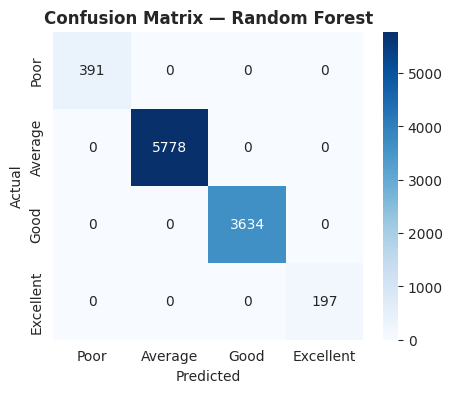

In [20]:
preds = best_pipe.predict(X_test)

class_names = ['Poor', 'Average', 'Good', 'Excellent']

print(classification_report(y_test, preds, target_names=class_names))

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix — {best_model_name}',fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

**Feature importance**

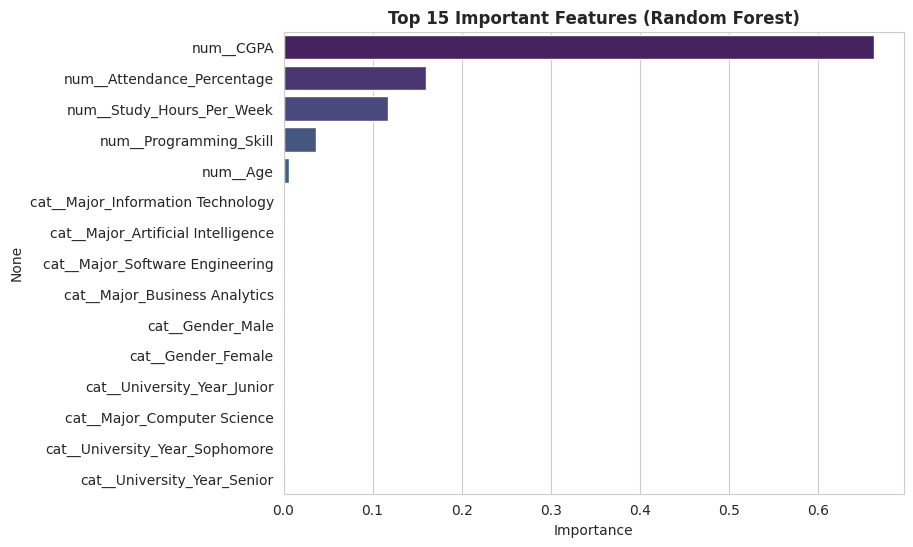

In [21]:
rf_model = results['Random Forest']['model']
feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()
importances = rf_model.named_steps['model'].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Top 15 Important Features (Random Forest)',fontweight='bold')
plt.xlabel('Importance')
plt.show()